# Cross-Subject Analysis:

This notebook analyzes cross-subject training results comparing models with and without knowledge graph enhancement.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linewidth'] = 0.8

sns.set_palette("colorblind")

In [2]:
def load_cross_subject_metrics(subject, model="flatnet", use_kg=False):
    """Load metrics.csv for cross-subject training"""
    model_name = f"{model}_kg" if use_kg else model
    path = Path(f"../logs/train/runs/{model}_cross/{model_name}_{subject}/csv/version_0/metrics.csv")
    if path.exists():
        return pd.read_csv(path)
    return None

def extract_test_metrics(df):
    """Extract test metrics from metrics dataframe"""
    if df is None:
        return None
    test_row = df[df['test/loss'].notna()].iloc[-1] if not df[df['test/loss'].notna()].empty else None
    if test_row is not None:
        return {
            'test_loss': test_row['test/loss'],
            'test_top1_acc_200': test_row['test/top1_acc_retrieval_200'],
            'test_top5_acc_200': test_row['test/top5_acc_retrieval_200']
        }
    return None

In [3]:
model = "flatnet"
subjects = [f"sub-{i:02d}" for i in range(1, 11)]

# Load baseline (without KG)
baseline_results = []
for subject in subjects:
    df = load_cross_subject_metrics(subject, model, use_kg=False)
    metrics = extract_test_metrics(df)
    if metrics:
        metrics['subject'] = subject
        baseline_results.append(metrics)

baseline_df = pd.DataFrame(baseline_results)
print(f"Loaded baseline data for {len(baseline_df)} subjects")
baseline_df

Loaded baseline data for 10 subjects


,test_loss,test_top1_acc_200,test_top5_acc_200,subject
0,4.313033,0.085,0.235,sub-01
1,4.069796,0.080,0.300,sub-02
2,4.326399,0.040,0.230,sub-03
3,4.818666,0.080,0.230,sub-04
4,4.047145,0.060,0.270,sub-05
5,4.592875,0.040,0.240,sub-06
6,4.591137,0.050,0.190,sub-07
7,4.132170,0.065,0.250,sub-08
8,4.172554,0.075,0.270,sub-09
9,3.940440,0.135,0.310,sub-10


In [4]:
# Load KG version
kg_results = []
for subject in subjects:
    df = load_cross_subject_metrics(subject, model, use_kg=True)
    metrics = extract_test_metrics(df)
    if metrics:
        metrics['subject'] = subject
        kg_results.append(metrics)

kg_df = pd.DataFrame(kg_results)
print(f"Loaded KG data for {len(kg_df)} subjects")
kg_df

Loaded KG data for 10 subjects


,test_loss,test_top1_acc_200,test_top5_acc_200,subject
0,4.093616,0.105,0.275,sub-01
1,4.061546,0.085,0.300,sub-02
2,4.465602,0.055,0.215,sub-03
3,4.730789,0.090,0.210,sub-04
4,4.077094,0.070,0.270,sub-05
5,4.502329,0.025,0.240,sub-06
6,4.706943,0.060,0.185,sub-07
7,4.198257,0.065,0.275,sub-08
8,4.361421,0.040,0.255,sub-09
9,4.065852,0.120,0.310,sub-10


## Comparison: Model vs Model+KG

Visual comparison of cross-subject performance with and without knowledge graph enhancement.

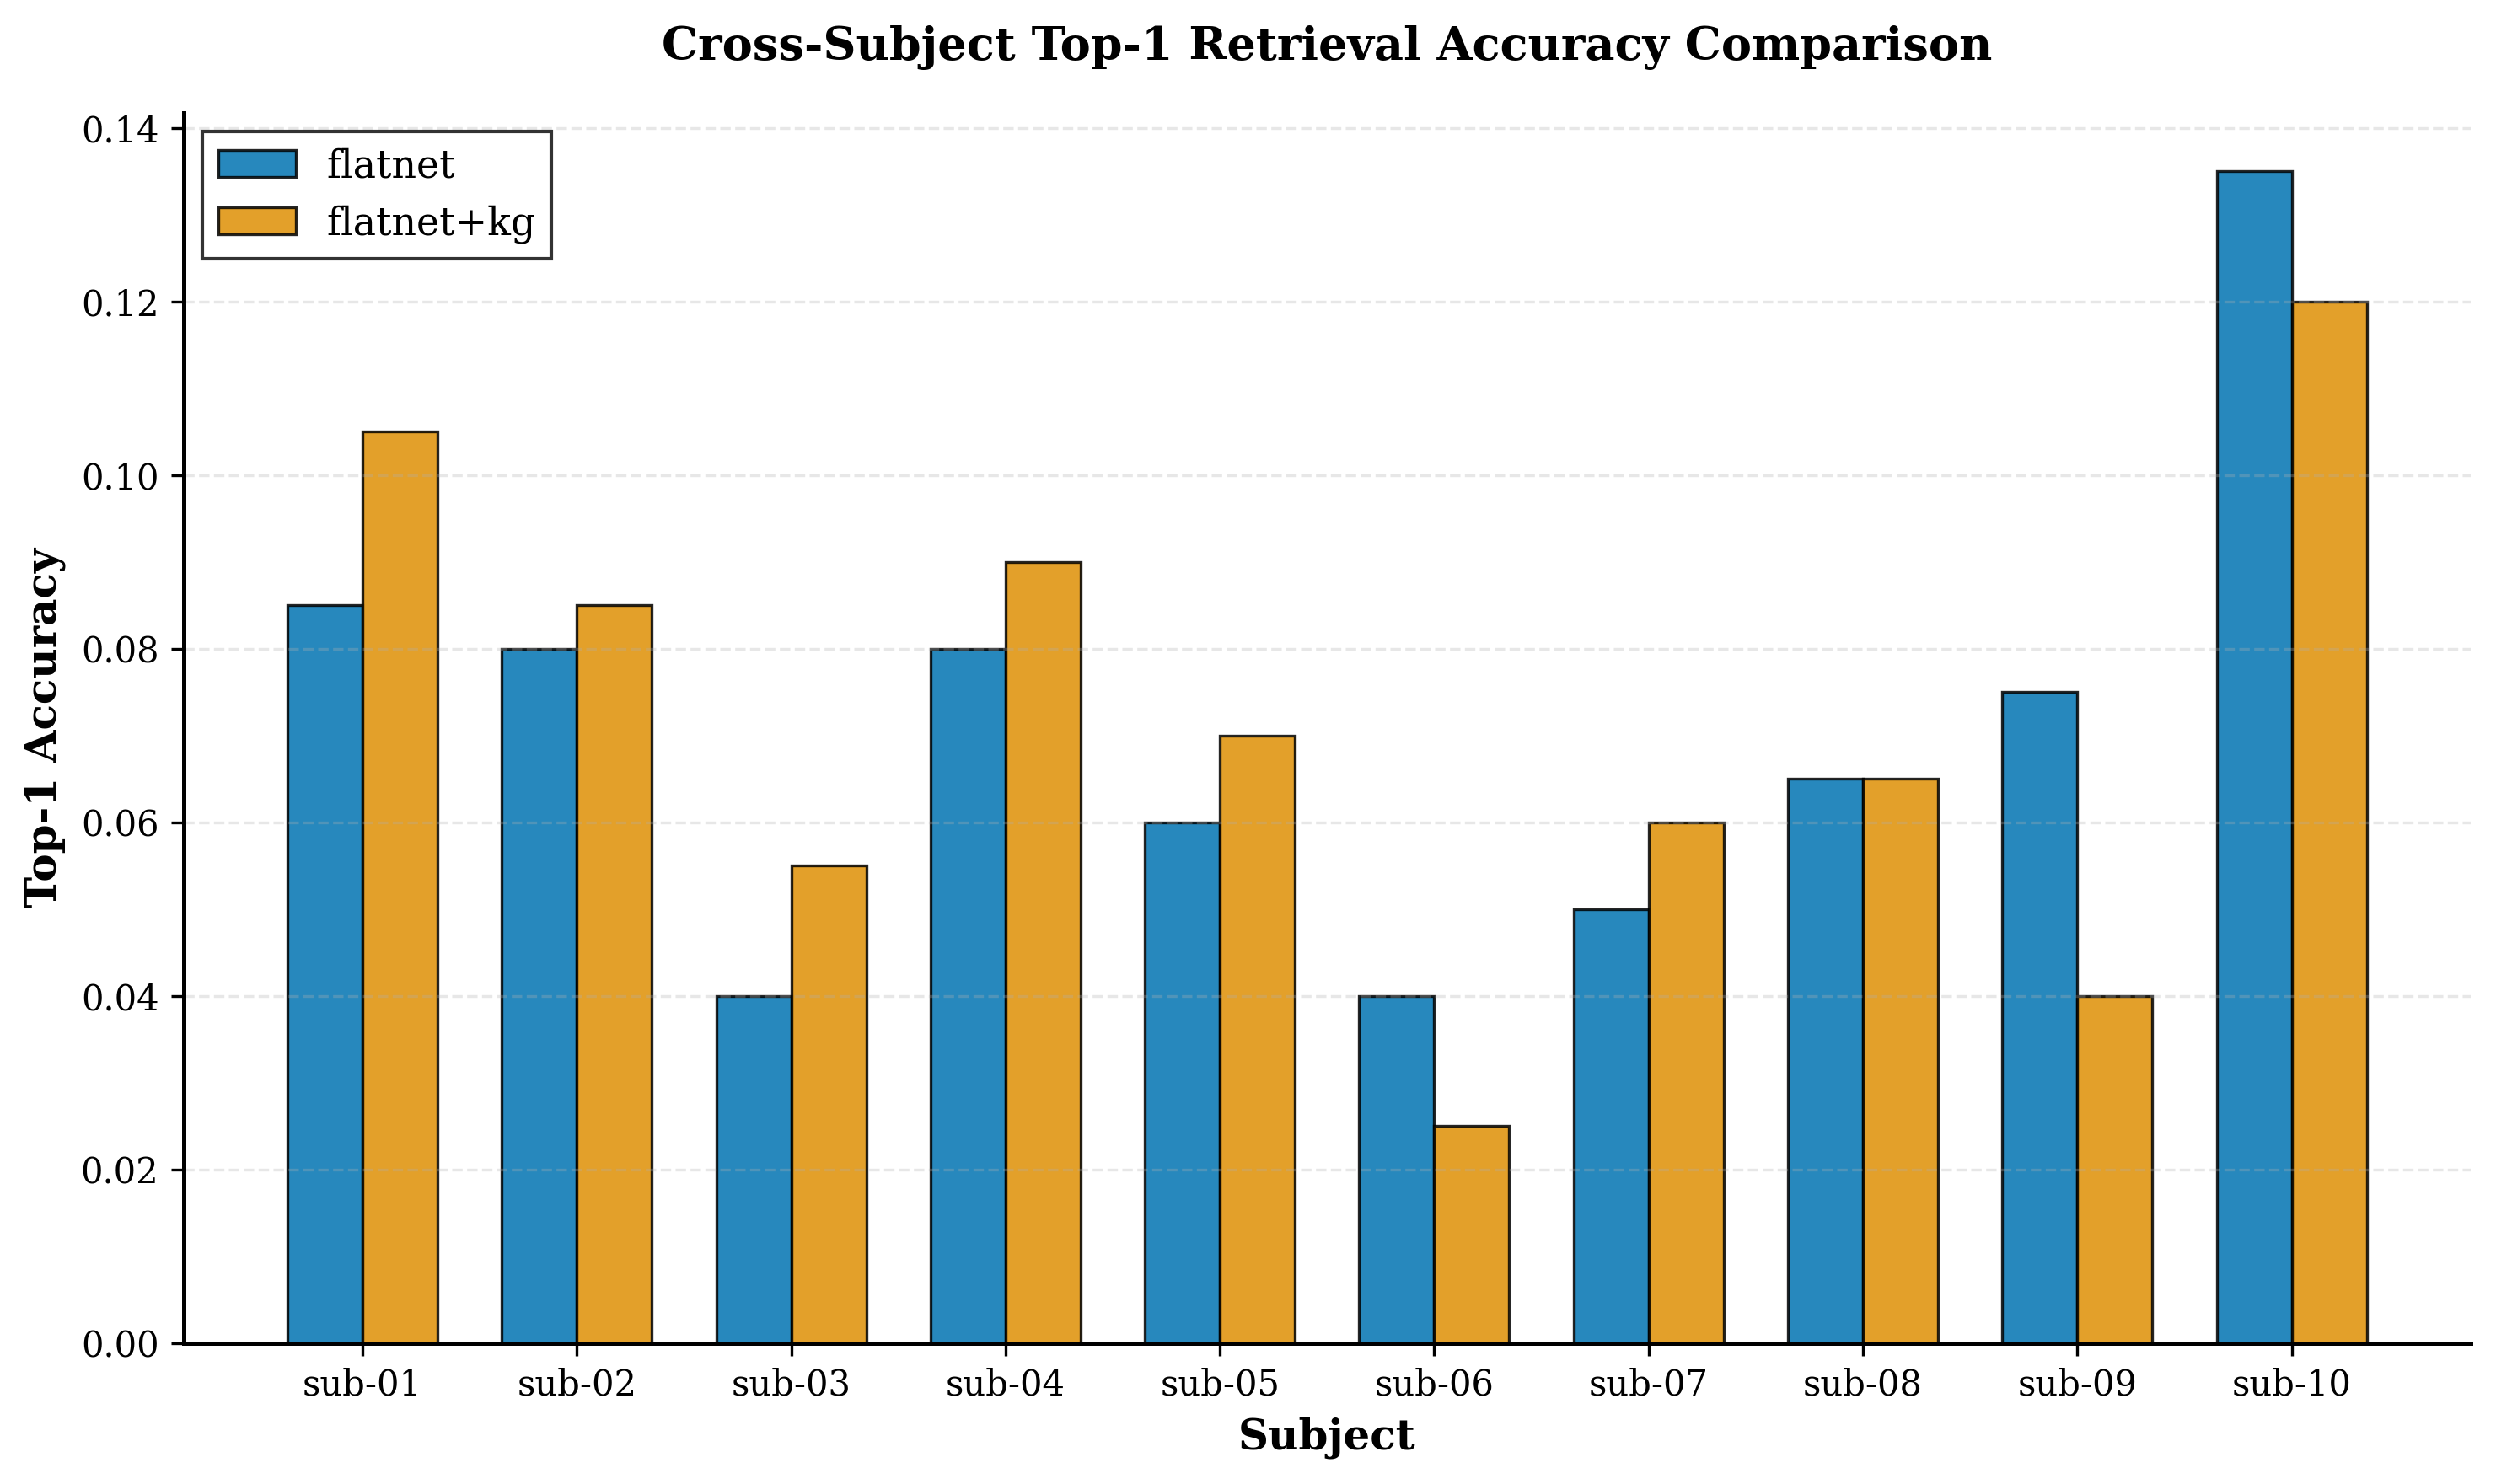

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(baseline_df))
width = 0.35

colors = sns.color_palette("colorblind")
ax.bar(x - width/2, baseline_df['test_top1_acc_200'], width, 
       capsize=4, alpha=0.85, label=f'{model}', color=colors[0], edgecolor='black', linewidth=0.8)
ax.bar(x + width/2, kg_df['test_top1_acc_200'], width, 
       capsize=4, alpha=0.85, label=f'{model}+kg', color=colors[1], edgecolor='black', linewidth=0.8)

ax.set_xlabel('Subject', fontweight='bold')
ax.set_ylabel('Top-1 Accuracy', fontweight='bold')
ax.set_title('Cross-Subject Top-1 Retrieval Accuracy Comparison', fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(baseline_df['subject'])
ax.legend(frameon=True, fancybox=False, edgecolor='black')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

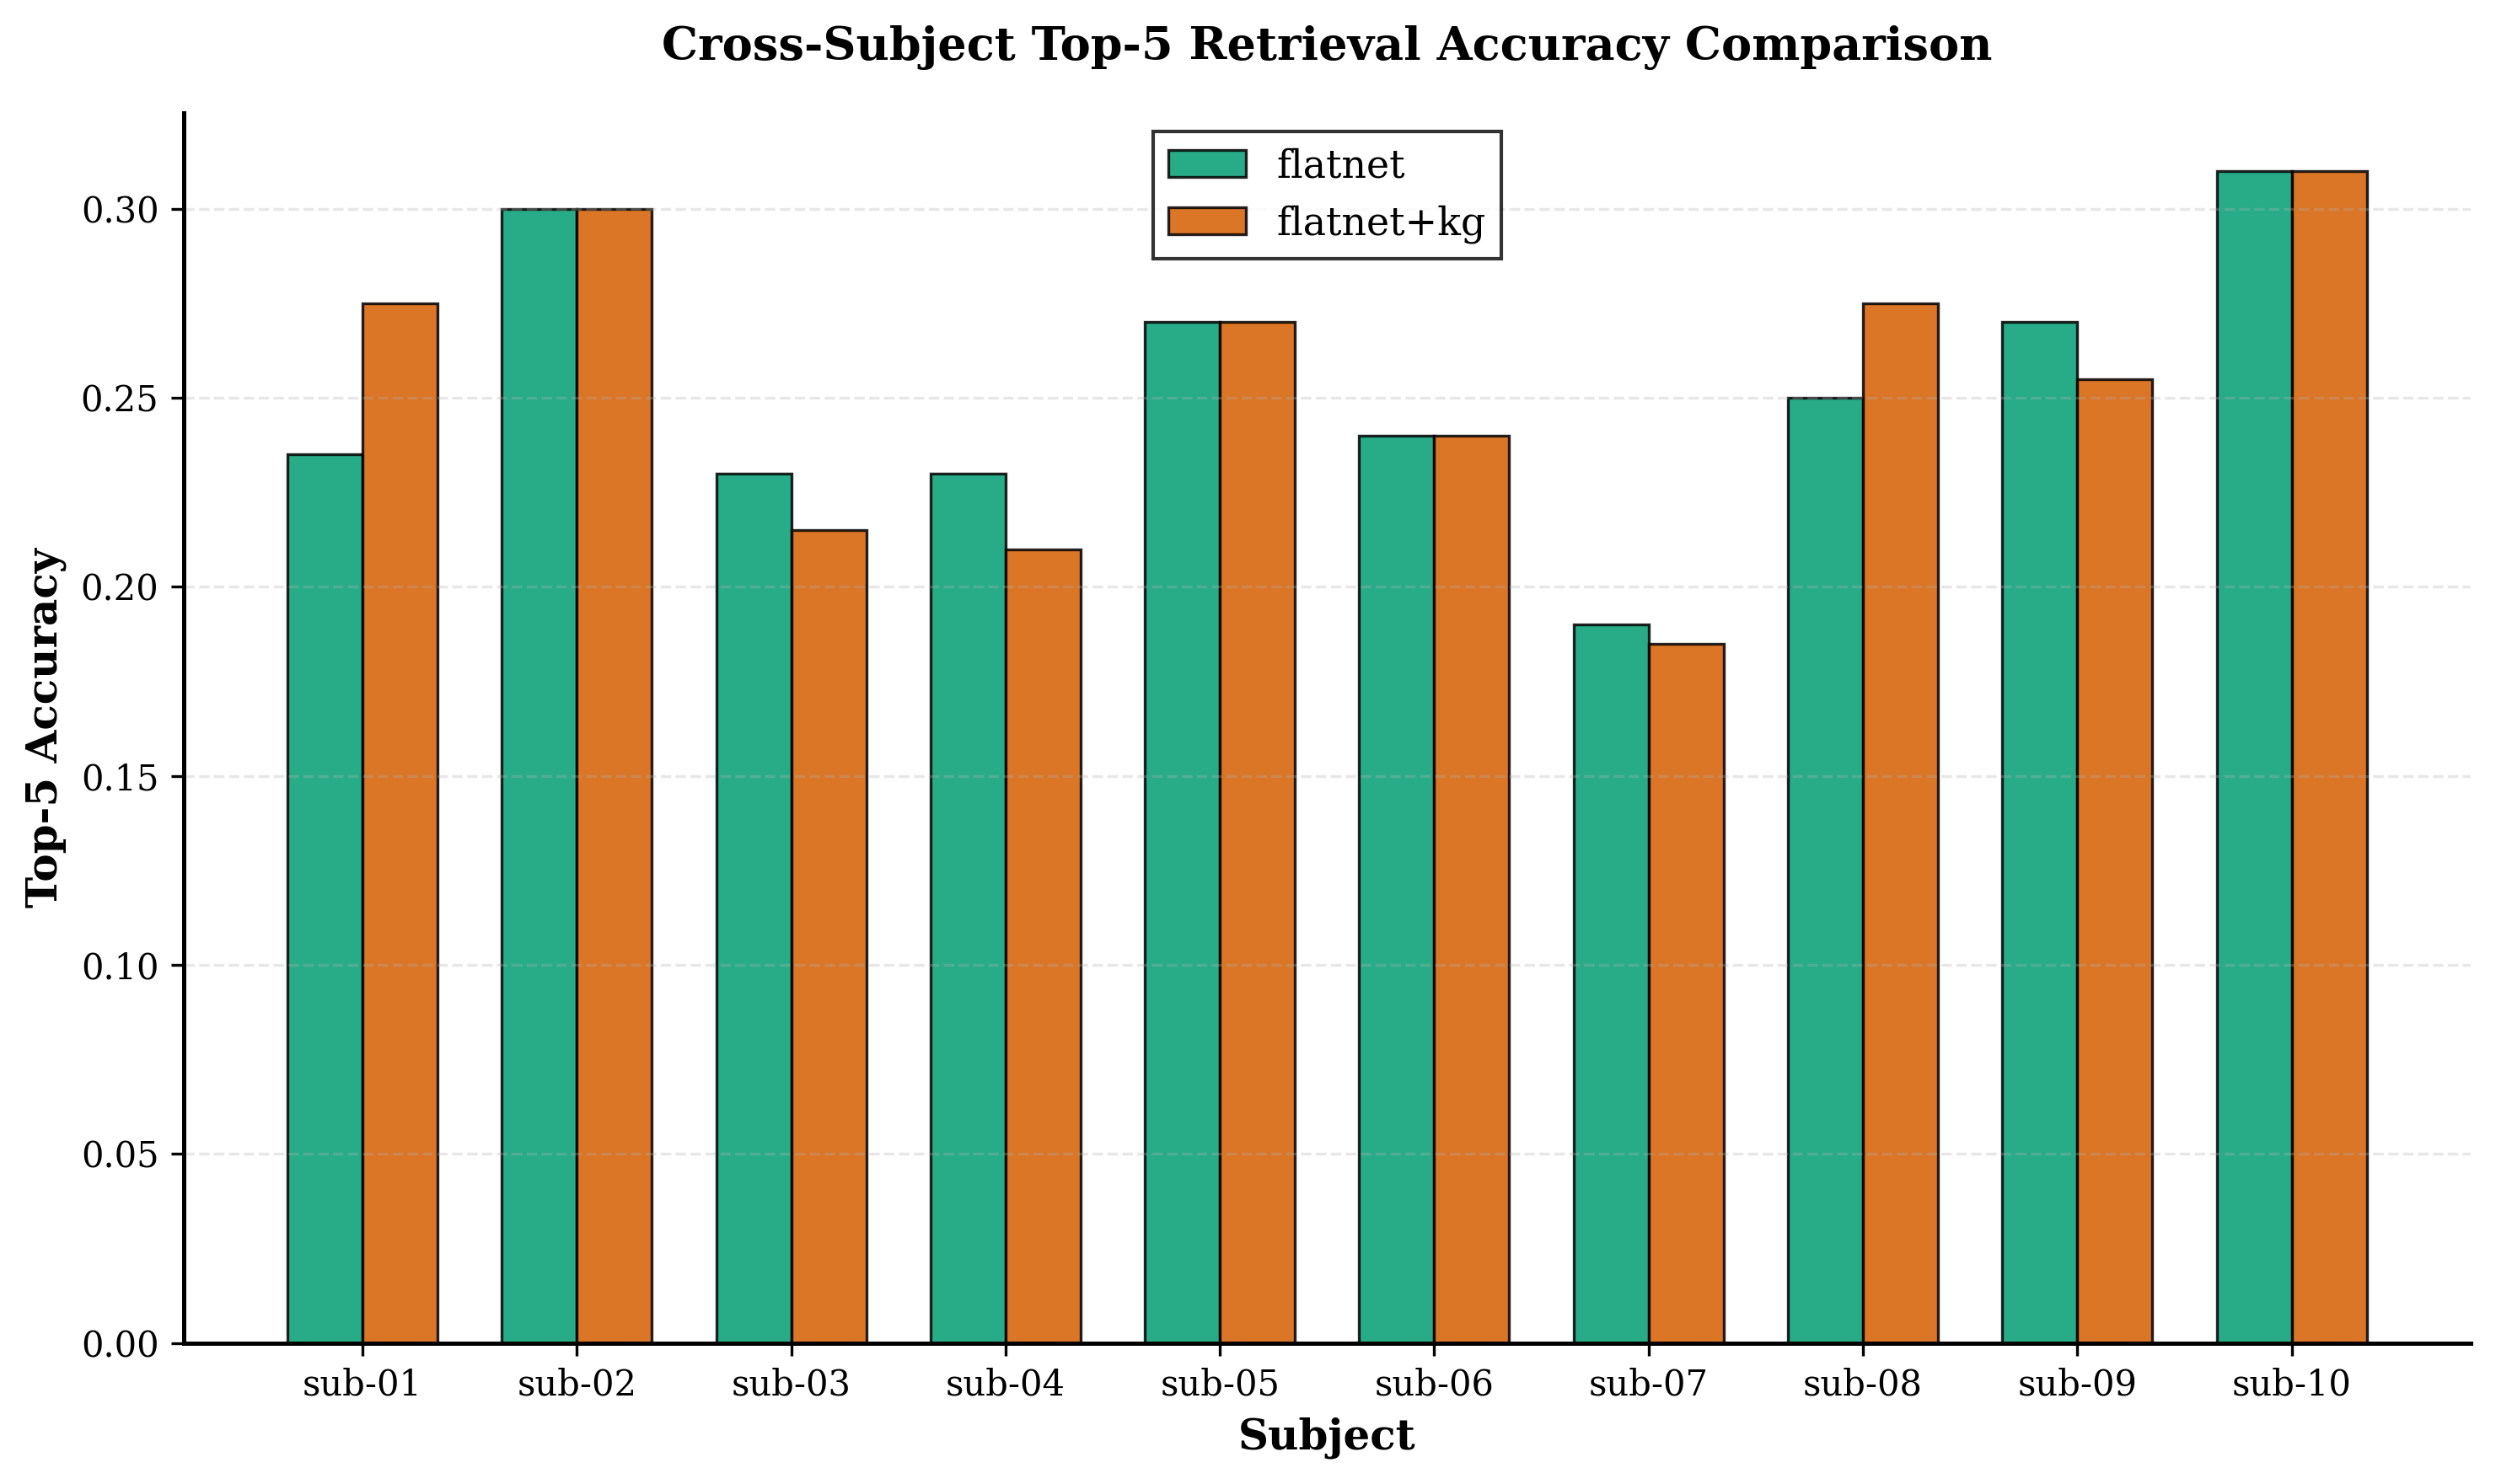

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(baseline_df))
width = 0.35

colors = sns.color_palette("colorblind")
ax.bar(x - width/2, baseline_df['test_top5_acc_200'], width, 
       capsize=4, alpha=0.85, label=f'{model}', color=colors[2], edgecolor='black', linewidth=0.8)
ax.bar(x + width/2, kg_df['test_top5_acc_200'], width, 
       capsize=4, alpha=0.85, label=f'{model}+kg', color=colors[3], edgecolor='black', linewidth=0.8)

ax.set_xlabel('Subject', fontweight='bold')
ax.set_ylabel('Top-5 Accuracy', fontweight='bold')
ax.set_title('Cross-Subject Top-5 Retrieval Accuracy Comparison', fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(baseline_df['subject'])
ax.legend(frameon=True, fancybox=False, edgecolor='black')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

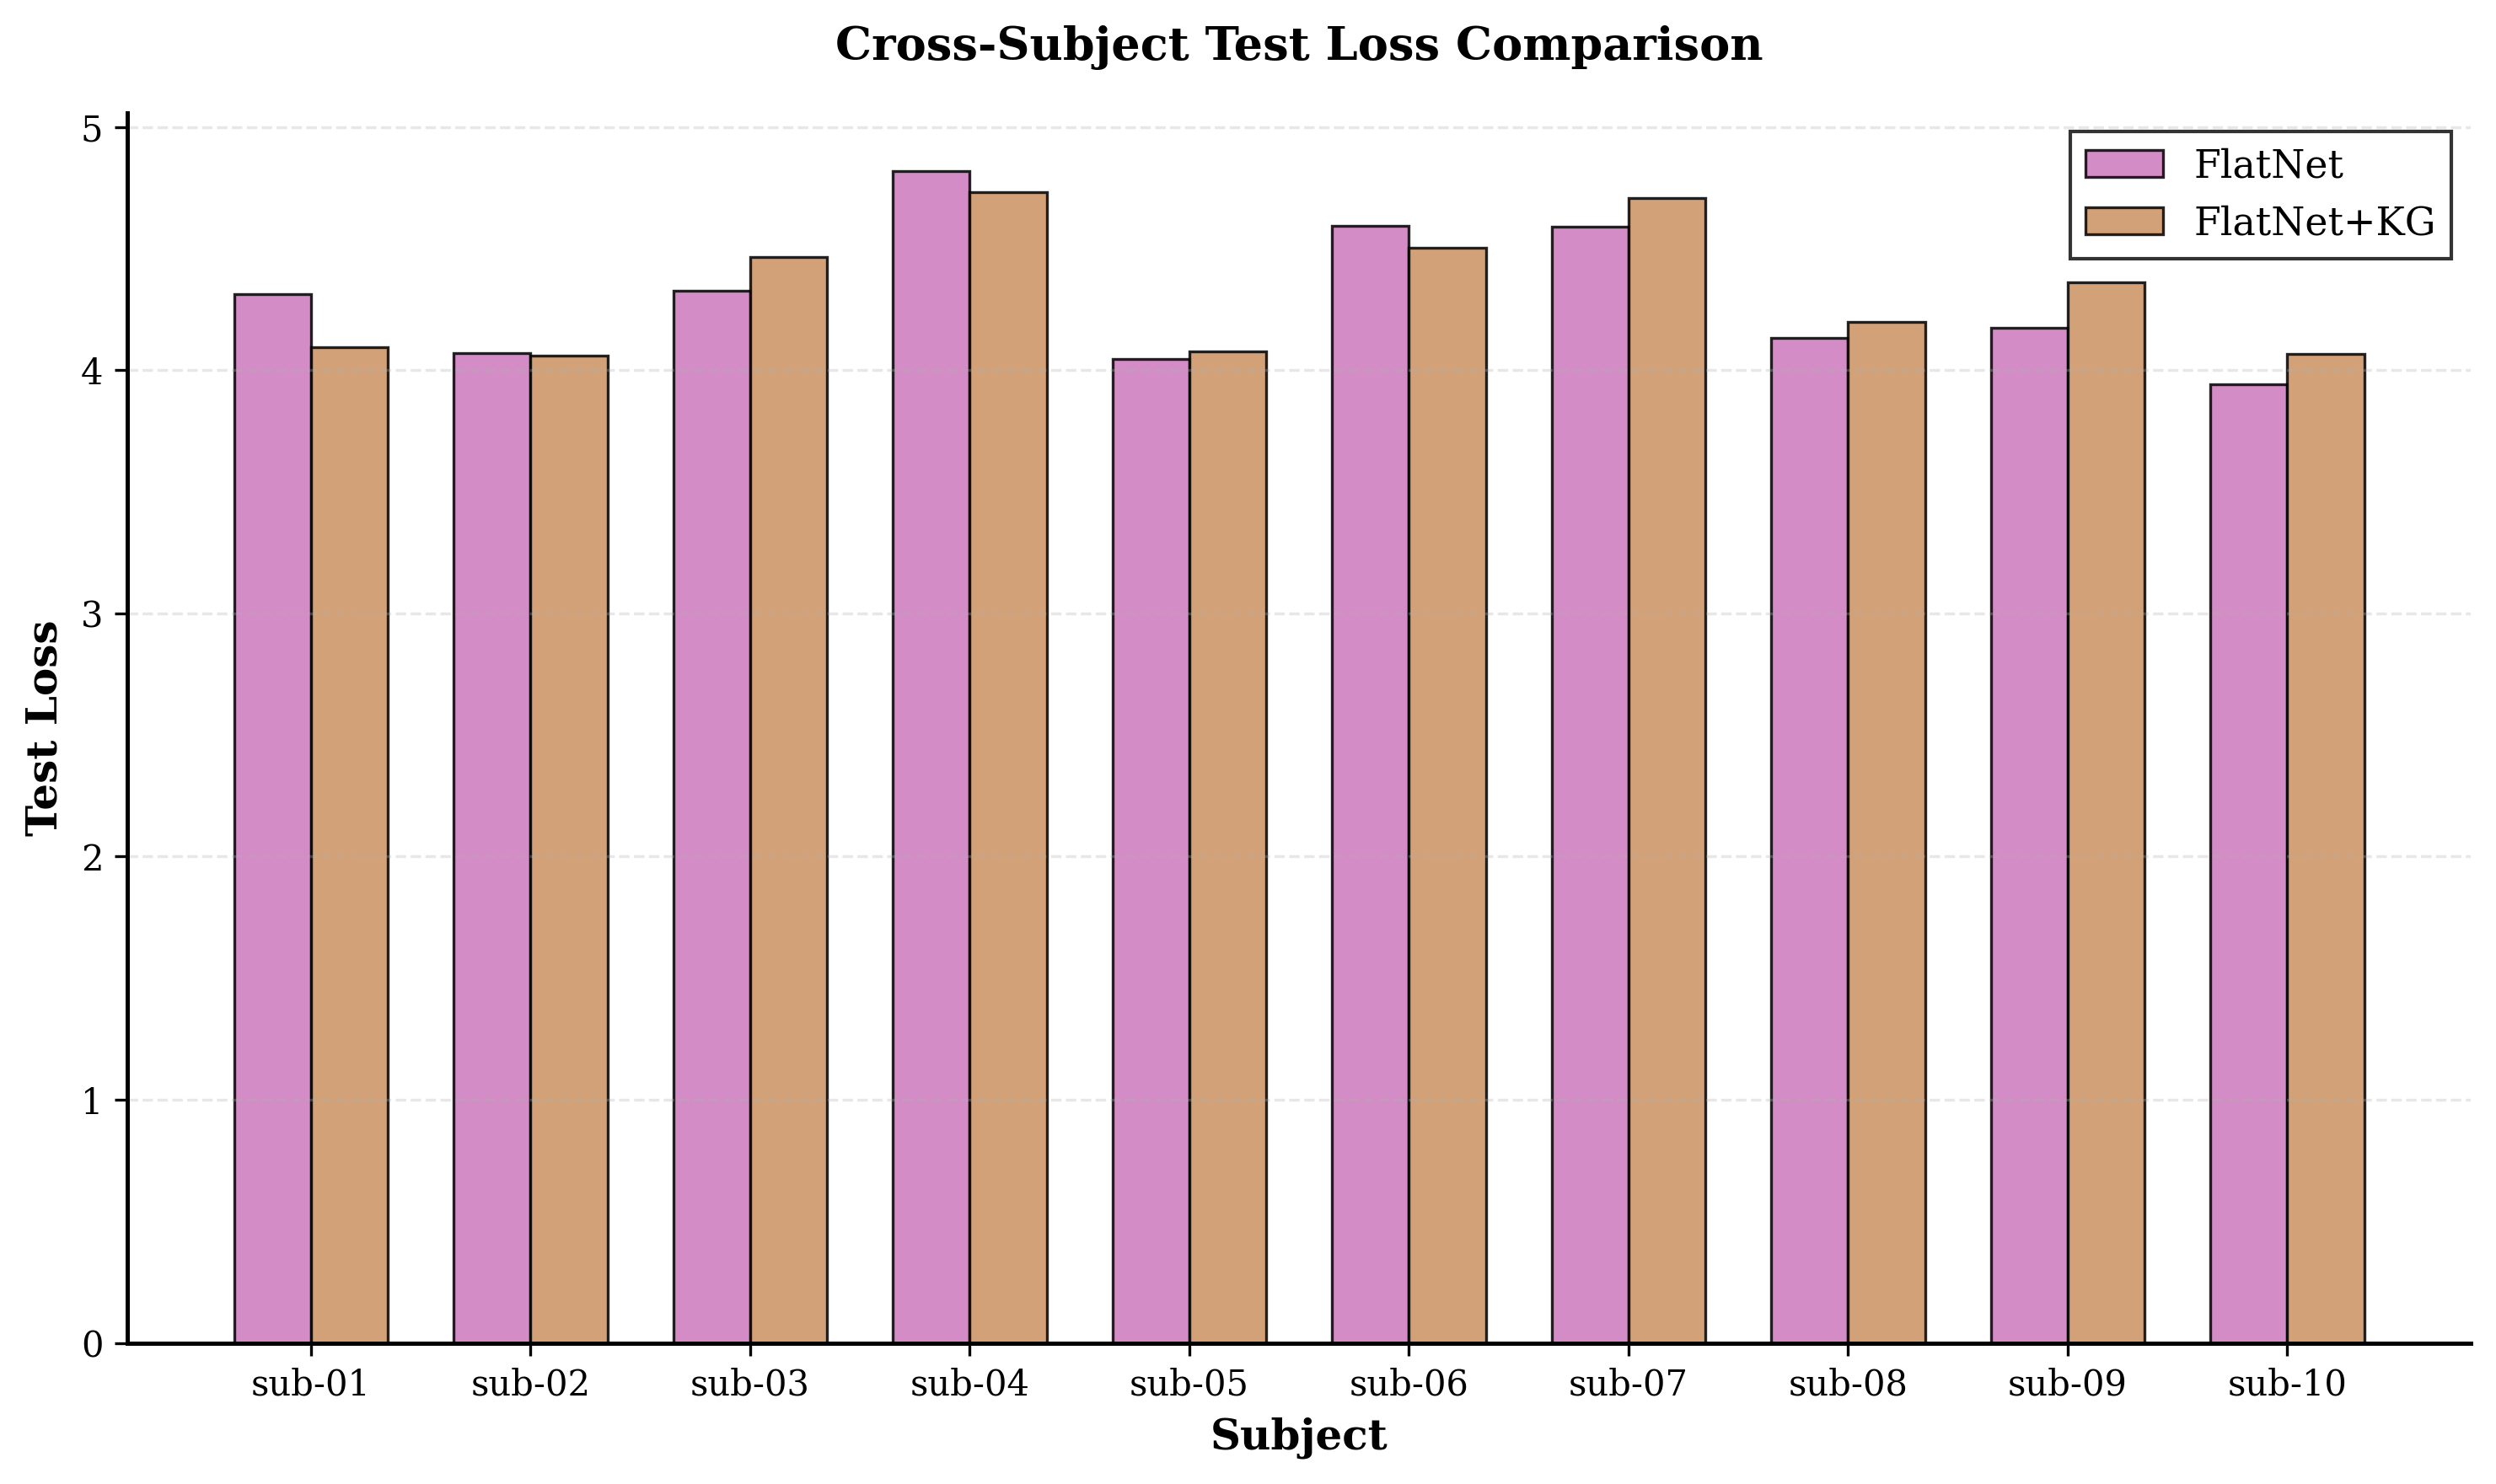

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(baseline_df))
width = 0.35

colors = sns.color_palette("colorblind")
ax.bar(x - width/2, baseline_df['test_loss'], width, 
       capsize=4, alpha=0.85, label='FlatNet', color=colors[4], edgecolor='black', linewidth=0.8)
ax.bar(x + width/2, kg_df['test_loss'], width, 
       capsize=4, alpha=0.85, label='FlatNet+KG', color=colors[5], edgecolor='black', linewidth=0.8)

ax.set_xlabel('Subject', fontweight='bold')
ax.set_ylabel('Test Loss', fontweight='bold')
ax.set_title('Cross-Subject Test Loss Comparison', fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(baseline_df['subject'])
ax.legend(frameon=True, fancybox=False, edgecolor='black')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [8]:
improvement = pd.DataFrame({
    'subject': baseline_df['subject'],
    'top1_improvement': ((kg_df['test_top1_acc_200'].values - baseline_df['test_top1_acc_200'].values) / baseline_df['test_top1_acc_200'].values * 100),
    'top5_improvement': ((kg_df['test_top5_acc_200'].values - baseline_df['test_top5_acc_200'].values) / baseline_df['test_top5_acc_200'].values * 100),
    'loss_improvement': ((baseline_df['test_loss'].values - kg_df['test_loss'].values) / baseline_df['test_loss'].values * 100)
})

print("Improvement with Knowledge Graph (%):")
print(f"Average Top-1 Accuracy: {improvement['top1_improvement'].mean():.2f}%")
print(f"Average Top-5 Accuracy: {improvement['top5_improvement'].mean():.2f}%")
print(f"Average Loss Reduction: {improvement['loss_improvement'].mean():.2f}%")
print("\nPer-subject improvement:")
improvement

Improvement with Knowledge Graph (%):
Average Top-1 Accuracy: 2.12%
Average Top-5 Accuracy: 0.36%
Average Loss Reduction: -0.67%

Per-subject improvement:


,subject,top1_improvement,top5_improvement,loss_improvement
0,sub-01,23.529407,17.021279,5.087315
1,sub-02,6.250003,0.000000,0.202707
2,sub-03,37.500002,-6.521740,-3.217527
3,sub-04,12.499998,-8.695651,1.823685
4,sub-05,16.666670,0.000000,-0.740008
5,sub-06,-37.500002,0.000000,1.971438
6,sub-07,20.000004,-2.631576,-2.522374
7,sub-08,0.000000,10.000002,-1.599347
8,sub-09,-46.666665,-5.555551,-4.526415
9,sub-10,-11.111107,0.000000,-3.182702
